In [ ]:

import sqlite3

# Create or connect to the SQLite database
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

# Create sales table
cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    product TEXT,
    quantity INTEGER,
    price REAL
)
""")

# Insert different sample data
sample_data = [
    ('Item X', 12, 4.5),
    ('Item Y', 18, 2.5),
    ('Item Z', 10, 7.5),
    ('Item X', 8, 4.5),
    ('Item Y', 15, 2.5),
    ('Item W', 9, 6.0),
    ('Item Z', 6, 7.5)
]

cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sample_data)

# Save and close
conn.commit()
conn.close()

Basic Sales Report:
  product  total_quantity  total_revenue
0  Item W               9           54.0
1  Item X              20           90.0
2  Item Y              33           82.5
3  Item Z              16          120.0


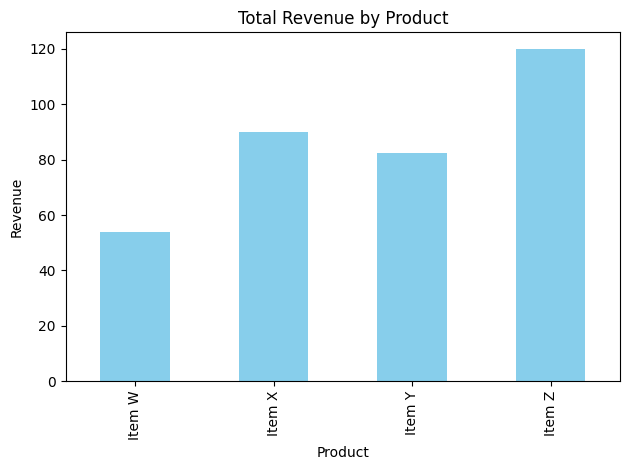

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the database
conn = sqlite3.connect("sales_data.db")

# SQL query to fetch total quantity and revenue per item
query = """
SELECT product,
       SUM(quantity) AS total_quantity,
       SUM(quantity * price) AS total_revenue
FROM sales
GROUP BY product
"""

# Load the query result into a DataFrame
df = pd.read_sql_query(query, conn)
conn.close()

# Display results
print("Basic Sales Report:")
print(df)

# Create a bar chart for revenue
df.plot(kind='bar', x='product', y='total_revenue', color='skyblue', legend=False)
plt.title("Total Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("revenue_chart.png")
plt.show()